# Geoword Testing Environment
For building multiple examples of geoword sequences

In [2]:
%load_ext autoreload
import pyvista as pv

from geogen.generation import *
import geogen.model as geo
import geogen.plot as geovis

pv.set_jupyter_backend("client")

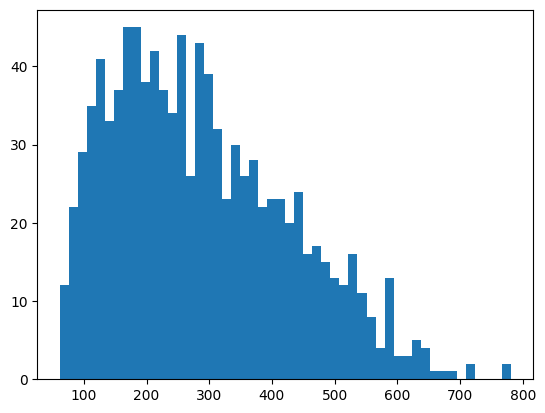

In [2]:
import geogen.probability as rv
import numpy as np
# Testing amplitude rv
n_samples = 1000
amps = np.zeros(n_samples)
for i in range(n_samples):
    amps[i] = rv.beta_min_max(1.8, 5.5, 60,1000)
    
import matplotlib.pyplot as plt
plt.hist(amps, bins=50)
plt.show()

## Batch Viewer

In [3]:
%aimport geogen.generation.geowords
%aimport geogen.generation.categorical_events

# List of geological words to generate
sentence = [BaseStrata(), FaultSequence()]

# Model resolution and bounds
z = 64
res = (2*z, 2*z, z)
bounds = (BOUNDS_X, BOUNDS_Y, BOUNDS_Z) # Bounds imported from generation (geowords file)
# res = (z, z, z)
# bounds = ((-1920, 1920),(-1920, 1920),(-1920, 1920))
test_viewer = geovis.GeoWordPlotter(sentence, bounds, res, 9, clim = (0,13))

## Markov Sampler Viewer

In [4]:
from geogen.generation.model_generators import MarkovGeostoryGenerator

# Generate a geostory
# Model resolution and bounds
z = 32
res = (2*z, 2*z, z)
bounds = (BOUNDS_X, BOUNDS_Y, BOUNDS_Z) # Bounds imported from generation (geowords file)
gen = MarkovGeostoryGenerator()
seq = gen._build_markov_sequence()

sentence = gen.build_sentence()

# Convert sentence to a history
hist = [word.generate() for word in sentence]

print(hist)

# test_viewer = geovis.GeoWordPlotter(sentence, bounds, res, 9, clim = (0,13))

[<geogen.model.geoprocess.CompoundProcess object at 0x00000240044BC8D0>, <geogen.model.geoprocess.CompoundProcess object at 0x000002407D5D1DD0>, <geogen.model.geoprocess.CompoundProcess object at 0x000002407A4DBD90>, <geogen.model.geoprocess.CompoundProcess object at 0x00000240044CDBD0>, <geogen.model.geoprocess.CompoundProcess object at 0x00000240044CDD50>, <geogen.model.geoprocess.CompoundProcess object at 0x00000240044CE090>, <geogen.model.geoprocess.CompoundProcess object at 0x00000240044CE190>, <geogen.model.geoprocess.CompoundProcess object at 0x0000024079DFEA50>]


# Random Markov Sampler

In [3]:
import torch
from torch.utils.data import DataLoader
from geogen.dataset import GeoData3DStreamingDataset

bounds = (BOUNDS_X, BOUNDS_Y, BOUNDS_Z)

def get_data_loader(batch_size, device, shuffle=True):
    z = 64
    res = (2*z, 2*z, z)
    bounds = (BOUNDS_X, BOUNDS_Y, BOUNDS_Z)
    
    dataset = GeoData3DStreamingDataset(
        model_resolution= res,
        model_bounds=bounds,  # Bounds of the model
        dataset_size=100,  # Number of samples in one epoch
        device=device,
    )
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, num_workers=4
    )
    return dataloader

loader = get_data_loader(40, 'cpu')

In [ ]:
"""
PyTorch DataLoader for streaming GeoWord geological histories. 
"""

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

# Two types of geological model generators provided
from geogen.generation import MarkovGeostoryGenerator

_DEFAULT_GENERATOR_CLASS = MarkovGeostoryGenerator


class GeoData3DStreamingDataset(Dataset):
    """
    A PyTorch Dataset wrapper for streaming geological data from a GeostoryGenerator object.

    Parameters
    ----------
    model_bounds : tuple
        Bounds of the model as ((xmin, xmax), (ymin, ymax), (zmin, zmax)).
    model_resolution : tuple
        Resolution of the model as (x_res, y_res, z_res).
    generator_config : str
        A path to a configuration file for the particular generator class.
    dataset_size : int
        The total number of samples in one epoch.
    device : str
        Torch device where data is loaded.
    """

    def __init__(
        self,
        model_bounds=((-3840, 3840), (-3840, 3840), (-1920, 1920)),
        model_resolution=(256, 256, 128),
        generator_config=None,
        dataset_size=int(1e6),
        device="cpu",
        transform=None,  # Add the transform parameter
    ):
        self.model_generator = _DEFAULT_GENERATOR_CLASS(
            model_bounds=model_bounds,
            model_resolution=model_resolution,
            config=generator_config,
        )
        self.device = device
        self.size = dataset_size
        self.transform = transform  # Store the transform

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        model = self.model_generator.generate_model()
        model.fill_nans()
        data = model.get_data_grid()
        data_tensor = torch.from_numpy(data).float().unsqueeze(0).to(self.device)

        return model, data_tensor

In [4]:
# get a batch of data
batch = next(iter(loader))

tensor([[[[ 4.,  4.,  4.,  ..., -1., -1., -1.],
          [ 3.,  3.,  3.,  ..., -1., -1., -1.],
          [ 1.,  1.,  3.,  ..., -1., -1., -1.],
          ...,
          [ 5.,  5.,  5.,  ..., -1., -1., -1.],
          [ 5.,  5.,  5.,  ..., -1., -1., -1.],
          [ 5.,  5.,  5.,  ..., -1., -1., -1.]],

         [[ 4.,  4.,  4.,  ..., -1., -1., -1.],
          [ 4.,  3.,  3.,  ..., -1., -1., -1.],
          [ 1.,  1.,  3.,  ..., -1., -1., -1.],
          ...,
          [ 5.,  5.,  5.,  ..., -1., -1., -1.],
          [ 5.,  5.,  5.,  ..., -1., -1., -1.],
          [ 5.,  5.,  5.,  ..., -1., -1., -1.]],

         [[ 4.,  4.,  4.,  ..., -1., -1., -1.],
          [ 4.,  4.,  4.,  ..., -1., -1., -1.],
          [ 1.,  1.,  3.,  ..., -1., -1., -1.],
          ...,
          [ 5.,  5.,  5.,  ..., -1., -1., -1.],
          [ 5.,  5.,  5.,  ..., -1., -1., -1.],
          [ 5.,  5.,  5.,  ..., -1., -1., -1.]],

         ...,

         [[ 3.,  3.,  3.,  ..., -1., -1., -1.],
          [ 3.,  3.,  

In [5]:
# Convert back to models
models = [geo.GeoModel.from_tensor(batch[i], bounds) for i in range(len(batch))]

In [6]:
import pyvista as pv
import geogen.plot as geovis

p = pv.Plotter(shape=(1,6), window_size=(1600,320))

for i in range(6):
    p.subplot(0,i)
    geovis.volview(models[i], p, clim = (0,13), show_bounds=False)
    
# Save the render to a file
p.screenshot("test.png")


pyvista_ndarray([[[  0,   0,   0],
                  [  0,   0,   0],
                  [  0,   0,   0],
                  ...,
                  [  0,   0,   0],
                  [  0,   0,   0],
                  [  0,   0,   0]],

                 [[  0,   0,   0],
                  [255, 255, 255],
                  [255, 255, 255],
                  ...,
                  [255, 255, 255],
                  [255, 255, 255],
                  [  0,   0,   0]],

                 [[  0,   0,   0],
                  [255, 255, 255],
                  [255, 255, 255],
                  ...,
                  [255, 255, 255],
                  [255, 255, 255],
                  [  0,   0,   0]],

                 ...,

                 [[  0,   0,   0],
                  [255, 255, 255],
                  [255, 255, 255],
                  ...,
                  [255, 255, 255],
                  [255, 255, 255],
                  [  0,   0,   0]],

                 [[  0,   0,   0],
  

In [47]:
"""
A module for plotting views and visualization of GeoModel objects.
"""

from typing import Optional

import numpy as np
import pyvista as pv

from geogen.model import GeoModel


def get_plot_config(n_colors=10):
    """Central color configurations and appearance settings for the plotter"""
    settings = {
        # Color map for the rock types
        "cmap": "gist_ncar",  # Vibrant color map to differentiate rock types
        # Scalar bar settings
    }
    return settings


def setup_plot(model: GeoModel, plotter: Optional[pv.Plotter] = None, threshold=-0.5):
    if plotter is None:
        plotter = pv.Plotter()

    if np.all(np.isnan(model.data)):
        plotter.add_text("No data to show, all values are NaN.", font_size=20)
        mesh = None
    else:
        mesh = get_voxel_grid_from_model(model, threshold)

    plot_config = get_plot_config()
    return plotter, mesh, plot_config


def volview(
    model: GeoModel,
    plotter: Optional[pv.Plotter] = None,
    threshold=-0.5,
    show_bounds=False,
    clim=None,
) -> pv.Plotter:
    """
    Visualize a volumetric view of the geological model with an optional bounding box.

    Parameters
    ----------
    model : GeoModel
        The geological model to be visualized. It contains the data and resolution information.
    plotter : pv.Plotter, optional
        The PyVista plotter to use for rendering the visualization. If not provided, a new one is created.
    threshold : float, optional
        Threshold value used to filter the voxel grid. Default is -0.5, values below this threshold are not shown.
    show_bounds : bool, optional
        If True, display the axis-aligned bounds and tick marks of the model. Default is False.

    Returns
    -------
    pv.Plotter
        The PyVista plotter object with the volumetric view rendered.
    """
    plotter, mesh, plot_config = setup_plot(model, plotter, threshold)
    if mesh is None:
        return plotter

    if clim:
        plot_config["clim"] = clim

    plotter.add_mesh(mesh, scalars="values", **plot_config, interpolate_before_map=False, show_scalar_bar=False)

    if show_bounds:
        plotter.show_bounds(
            grid="back",
            location="outer",
            ticks="outside",
            n_xlabels=4,
            n_ylabels=4,
            n_zlabels=4,
            xtitle="Easting",
            ytitle="Northing",
            ztitle="Elevation",
            all_edges=True,
        )

    flat_bounds = [item for sublist in model.bounds for item in sublist]
    bounding_box = pv.Box(flat_bounds)
    plotter.add_mesh(bounding_box, color="black", style="wireframe", line_width=1)

    return plotter


def orthsliceview(model: GeoModel, plotter: Optional[pv.Plotter] = None, threshold=-0.5) -> pv.Plotter:
    """
    Visualize using interactive orthogonal slices of the geological model.

    Parameters
    ----------
    model : GeoModel
        The geological model to be sliced and visualized.
    plotter : pv.Plotter, optional
        The PyVista plotter to use for rendering. If not provided, a new one is created.
    threshold : float, optional
        Threshold value used to filter the voxel grid. Default is -0.5, values below this threshold are not shown.

    Returns
    -------
    pv.Plotter
        The PyVista plotter object with orthogonal slices rendered.
    """
    plotter, mesh, plot_config = setup_plot(model, plotter, threshold)
    if mesh is None:
        return plotter

    plotter.add_mesh_slice_orthogonal(mesh, scalars="values", **plot_config)
    plotter.add_axes(line_width=5)
    return plotter


def nsliceview(
    model: GeoModel, plotter: Optional[pv.Plotter] = None, n=5, axis="x", threshold=-0.5
) -> pv.Plotter:
    """
    Visualize multiple slices along a specified axis of the geological model.

    Parameters
    ----------
    model : GeoModel
        The geological model to be sliced and visualized.
    plotter : pv.Plotter, optional
        The PyVista plotter to use for rendering. If not provided, a new one is created.
    n : int, optional
        The number of slices to be extracted along the specified axis. Default is 5.
    axis : str, optional
        The axis along which to slice the model. Can be "x", "y", or "z". Default is "x".
    threshold : float, optional
        Threshold value to filter the voxel grid. Default is -0.5, values below this threshold are not shown.

    Returns
    -------
    pv.Plotter
        The PyVista plotter object with the slices rendered.
    """
    plotter, mesh, plot_config = setup_plot(model, plotter, threshold)
    if mesh is None:
        return plotter

    slices = mesh.slice_along_axis(n=n, axis=axis)
    plotter.add_mesh(slices, scalars="values", **plot_config)
    plotter.add_axes(line_width=5)
    return plotter


def onesliceview(model: GeoModel, plotter: Optional[pv.Plotter] = None, threshold=-0.5) -> pv.Plotter:
    """
    Visualize a single slice through the geological model, along with a translucent surface for context.

    Parameters
    ----------
    model : GeoModel
        The geological model to be sliced and visualized.
    plotter : pv.Plotter, optional
        The PyVista plotter to use for rendering. If not provided, a new one is created.
    threshold : float, optional
        Threshold value to filter the voxel grid. Default is -0.5, values below this threshold are not shown.

    Returns
    -------
    pv.Plotter
        The PyVista plotter object with the single slice and surface skin rendered.
    """
    plotter, mesh, plot_config = setup_plot(model, plotter, threshold)
    if mesh is None:
        return plotter

    skin = mesh.extract_surface()
    plotter.add_mesh_slice(mesh, **plot_config)
    plotter.add_mesh(
        skin,
        scalars="values",
        cmap=plot_config["cmap"],
        opacity=0.1,
        show_scalar_bar=False,
    )
    plotter.add_axes(line_width=5)
    return plotter


def transformationview(model: GeoModel, plotter: Optional[pv.Plotter] = None, threshold=None) -> pv.Plotter:
    """
    Visualize a time-sequenced transformation view of the geological model, showing snapshots of model deformations.

    Parameters
    ----------
    model : GeoModel
        The geological model containing the data and deformation snapshots to be visualized.
    plotter : pv.Plotter, optional
        The PyVista plotter to use for rendering. If not provided, a new one is created.
    threshold : float, optional
        Threshold value used to filter the voxel grid. Default is None, meaning no filtering will occur.

    Returns
    -------
    pv.Plotter
        The PyVista plotter object with the transformation snapshots rendered.
    """
    plotter, mesh, plot_config = setup_plot(model, plotter, threshold)
    if mesh is None:
        return plotter

    final_mesh = get_voxel_grid_from_model(model, threshold)
    final_actor = plotter.add_mesh(final_mesh, scalars="values", **plot_config)
    plotter.add_axes(line_width=5)

    # Get the colormap and scalar range (clim) from the final mesh plot
    # To use as reference for coloring in the snapshots
    clim = final_actor.mapper.scalar_range
    cmap = plot_config["cmap"]

    _add_snapshots_to_plotter(plotter, model, cmap, clim)
    return plotter


def _add_snapshots_to_plotter(plotter: pv.Plotter, model: GeoModel, cmap, clim):
    """
    Add historical deformation snapshots of the geological model to the plotter.

    Parameters
    ----------
    plotter : pv.Plotter
        The PyVista plotter to which the snapshots are added.
    model : GeoModel
        The geological model containing the mesh and data snapshots to visualize.
    cmap : str
        The colormap to use for the snapshots.
    clim : tuple
        The color limit range (clim) to ensure consistent scaling across the snapshots.

    Returns
    -------
    list
        A list of actors representing the deformation snapshots added to the plotter.
    """
    resolution = model.resolution
    # Calculate the offset to separate each snapshot
    # The offset is chosen based on the overall size of the model
    x_offset = model.bounds[0][1] - model.bounds[0][0]  # Width of the model along x

    # Remove first data time entry which is empty, add the final data time entry
    data_snapshots = np.concatenate((model.data_snapshots[1:], model.data.reshape(1, -1)), axis=0)

    # Reverse the snapshots for proper plotting
    mesh_snapshots = model.mesh_snapshots[::-1]
    data_snapshots = data_snapshots[::-1]

    actors = []
    for i, (mesh_snapshot, data_snapshot) in enumerate(zip(mesh_snapshots, data_snapshots)):
        # Assuming snapshots are stored as Nx3 arrays
        # Reshape to 3D grid of points-- i.e. 4x4x4 grid of (x,y,z) points
        deformed_points = mesh_snapshot.reshape(resolution + (3,))
        grid = pv.StructuredGrid(
            deformed_points[..., 0] + (i + 1) * x_offset * 1.3,  # Shift along x
            deformed_points[..., 1],
            deformed_points[..., 2],
        )
        # Set the same values to the new grid
        grid["values"] = data_snapshot.reshape(model.X.shape).flatten(
            order="F"
        )  # Assigning scalar values to the grid
        # Add grid to plotter using the same colormap and scalar range as the final mesh
        a = plotter.add_mesh(
            grid,
            style="wireframe",
            scalars="values",
            cmap=cmap,  # Use the colormap from the final mesh
            clim=clim,  # Use the scalar range from the final mesh
            line_width=1,
            show_scalar_bar=False,
        )
        actors.append(a)

    return actors


def categorical_grid_view(model: GeoModel, threshold=None, text_annot=True, off_screen=False) -> pv.Plotter:
    """
    Visualize categorical rock types from the geological model in a grid layout, with each category displayed separately.

    Parameters
    ----------
    model : GeoModel
        The geological model containing categorical rock type data.
    threshold : float, optional
        Threshold value used to filter the voxel grid. Default is None, meaning no filtering will occur.
    text_annot : bool, optional
        If True, display the rock type labels in each subplot. Default is True.
    off_screen : bool, optional
        If True, create the plotter off-screen. Useful for generating plots without a visible window. Default is False.

    Returns
    -------
    pv.Plotter
        The PyVista plotter object with categorical views rendered in subplots.
    """
    cfg = get_plot_config()

    def calculate_grid_dims(n):
        """Calculate grid dimensions that are as square as possible."""
        sqrt_n = np.sqrt(n)
        rows = np.ceil(sqrt_n)
        cols = rows
        return int(rows), int(cols)

    grid = get_voxel_grid_from_model(model, threshold=threshold)  # Get voxel grid
    cats = np.unique(grid["values"])  # Find unique categories

    num_cats = len(cats)
    rows, cols = calculate_grid_dims(num_cats)

    p = pv.Plotter(shape=(rows, cols), border=False, off_screen=off_screen)  # subplot square layout

    clim = [cats.min(), cats.max()]  # Preset color limits for all subplots
    skin = grid.extract_surface()  # Extract surface mesh for translucent skin

    for i, cat in enumerate(cats):
        row, col = divmod(i, cols)
        p.subplot(row, col)

        cat_mask = grid["values"] == cat  # mask for a category
        category_grid = grid.extract_cells(cat_mask)  # Pull only those cells from voxel grid

        # Plot the category cluster and a translucent skin for context
        p.add_mesh(
            skin,
            scalars="values",
            clim=clim,
            cmap=cfg["cmap"],
            opacity=0.2,
            show_scalar_bar=False,
        )
        p.add_mesh(
            category_grid,
            scalars="values",
            clim=clim,
            cmap=cfg["cmap"],
            opacity=1.0,
            show_scalar_bar=False,
        )

        if text_annot:
            p.add_text(f"Category {cat}", position="upper_left", font_size=10)

    # Link all views to synchronize interactions such as rotation and zooming
    p.link_views()
    return p


def get_mesh_from_model(model: GeoModel, threshold=None):
    """
    Convert a geological model's data into a structured grid mesh for visualization.

    Parameters
    ----------
    model : GeoModel
        The geological model containing the grid data and resolution.
    threshold : float, optional
        Threshold value to filter out cells with values below the threshold. Default is None, meaning no filtering.

    Returns
    -------
    pyvista.StructuredGrid
        The PyVista structured grid with scalar values assigned from the model's data.
    """

    if model.data is None or model.data.size == 0:
        raise ValueError("Model data is empty or not computed, no data to show. Use compute model first.")

    grid = pv.StructuredGrid(model.X, model.Y, model.Z)

    # Set data to the grid
    values = model.data.reshape(model.X.shape)
    grid["values"] = values.flatten(order="F")  # Flatten the data in Fortran order
    # Create mesh thresholding to exclude np.nan values or sentinel values
    mesh = grid.threshold(threshold, all_scalars=True)
    return mesh


def get_voxel_grid_from_model(model, threshold=None):
    """
    Convert the geological model's data into a voxel grid for visualization. The voxel grid contains discrete rock types.

    Parameters
    ----------
    model : GeoModel
        The geological model containing rock type data and resolution.
    threshold : float, optional
        Threshold value used to filter the voxel grid. Default is None, meaning no filtering will occur.

    Returns
    -------
    pyvista.ImageData
        The voxel grid representation of the geological model, with discrete values for rock types.
    """
    if model.data is None or model.data.size == 0:
        raise ValueError("Model data is empty or not computed, no data to show. Use compute model first.")
    if not all(res > 1 for res in model.resolution):
        raise ValueError("Voxel grid requires a model resolution greater than 1 in each dimension.")

    # Create a padded grid with n+1 nodes and node spacing equal to model sample spacing
    dimensions = tuple(x + 1 for x in model.resolution)
    spacing = tuple((x[1] - x[0]) / (r - 1) for x, r in zip(model.bounds, model.resolution))
    # pad origin with a half cell size to center the grid
    origin = tuple(x[0] - cs / 2 for x, cs in zip(model.bounds, spacing))

    # Create a structured grid with n+1 nodes in each dimension forming n^3 cells
    grid = pv.ImageData(
        dimensions=dimensions,
        spacing=spacing,
        origin=origin,
    )
    # Necessary to reshape data vector in Fortran order to match the grid
    grid["values"] = model.data.reshape(model.resolution).ravel(order="F")
    grid = grid.threshold(threshold, all_scalars=True)
    return grid


In [64]:
idx = [0, 5, 6, 8, 9, 10]
models_selected = [models[i] for i in idx]

p = pv.Plotter(shape=(1,6), window_size=(1600,220))

for i in range(6):
    p.subplot(0,i)
    volview(models_selected[i], p, clim=(0,13), show_bounds=False)
    
# Save the render to a file
p.screenshot("test.png")


pyvista_ndarray([[[  0,   0,   0],
                  [  0,   0,   0],
                  [  0,   0,   0],
                  ...,
                  [  0,   0,   0],
                  [  0,   0,   0],
                  [  0,   0,   0]],

                 [[  0,   0,   0],
                  [255, 255, 255],
                  [255, 255, 255],
                  ...,
                  [255, 255, 255],
                  [255, 255, 255],
                  [  0,   0,   0]],

                 [[  0,   0,   0],
                  [255, 255, 255],
                  [255, 255, 255],
                  ...,
                  [255, 255, 255],
                  [255, 255, 255],
                  [  0,   0,   0]],

                 ...,

                 [[  0,   0,   0],
                  [255, 255, 255],
                  [255, 255, 255],
                  ...,
                  [255, 255, 255],
                  [255, 255, 255],
                  [  0,   0,   0]],

                 [[  0,   0,   0],
  

## Single Viewer

In [2]:
%load_ext autoreload
%autoreload 2

from geogen.generation import *

# set numpy seed
np.random.seed(0)

# List of geological words to generate
sentence = [BaseStrata(), Sediment(), Fold(), Sediment(), Erosion()]
# Model resolution and bounds
z = 64
res = (2*z, 2*z, z)
bounds = (BOUNDS_X, BOUNDS_Y, BOUNDS_Z) # Bounds imported from generation (geowords file)
# bounds = ((-1920, 1920),(-1920, 1920),(-1920, 1920))

def generate_model_func():
    hist = generate_history(sentence)
    model = geo.GeoModel(bounds=bounds, resolution=res)
    model.add_history(hist)
    model.compute_model(normalize=True)    
    
    return model

mr = geovis.ModelReviewer(generate_model_func, './')

mr.start_review()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Output()

Model discarded.


Model discarded.


Model discarded.


Model discarded.


Model discarded.


Model discarded.


## Forming New GeoWords

The contract for a geoword is that it simply needs to have a `build_ history()` function that will populate the `self.history` field.  For example we want to pair a fault with a dike randomly placed in the model. We can create a new `GeoWord` object that will encapsulate the random variables and the underlying processes. 

In [ ]:
from geogen.model import Fault, DikePlane
from geogen.probability import random_point_in_ellipsoid
import numpy as np


class MyFaultDikeWord(GeoWord):
    def build_history(self):
        bounds = ((-3840, 3840), (-3840, 3840), (-1920, 1920))
        strike = np.random.uniform(0, 360)
        dip = np.random.uniform(75, 90)
        rake = np.random.uniform(0, 360)
        origin = random_point_in_ellipsoid(bounds)
        # First a Fault
        fault_params = {
            "strike": strike,
            "dip": dip,
            "rake": rake,
            "amplitude": np.random.lognormal(0, 0.25) * 200,
            "origin": origin,
        }
        fault = Fault(**fault_params)
        # Then a Dike in the same area
        dike_params = {
            "strike": strike,
            "dip": dip,
            "width": np.random.normal(150, 50),
            "origin": origin,
        }
        dike = DikePlane(**dike_params)

        self.add_process(fault)
        self.add_process(dike)
        # No return value needed

Now adding a new `GeoWord` object that encapsulates the fault and dike processes. To a sentence:

In [ ]:
sentence = [
    InfiniteBasement(),
    CoarseRepeatSediment(),
    FourierFold(),
    SingleRandSediment(),
    FineRepeatSediment(),
    MyFaultDikeWord(),
]

# Save directory for models
DEFAULT_BASE_DIR = "../saved_models"

# Model resolution and bounds
res = (256, 256, 128)
bounds = ((-3840, 3840), (-3840, 3840), (-1920, 1920))


def generate_model():
    # Generate a randomized history from geowords, one single sample
    hist = generate_history(sentence)
    model = geo.GeoModel(bounds=bounds, resolution=res)
    model.add_history(hist)
    model.compute_model(normalize=True)
    return model


reviewer = geovis.ModelReviewer(generate_model_func=generate_model, base_dir=DEFAULT_BASE_DIR)
reviewer.start_review()

Output()